In [1]:
%load_ext autoreload
%autoreload 2

# Feature Importances

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import shap
import torch
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tabpfn import TabPFNClassifier
from tqdm import tqdm

from roar import ALL_VEHICLES, MIC_CHANNELS, MIC_CHANNELS_CLEANED
from roar import DATA_DIR as DATA_ROOT
from roar.preprocessing import (
    extract_features_from_h5_file,
    fix_channel_names,
    get_channel_mapping,
    parse_filename,
)

device = (
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

/Users/moritzfeik/Developer/ROAR/.pixi/envs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Settings

In [3]:
LOGO_COLUMN = "vehicle"

In [4]:
TRACKS = ["track150", "track211"]
CARS = ALL_VEHICLES
TYRES = ["tyre1", "tyre3", "tyre6", "tyre10", "tyre12", "tyre13"]

#### Load & Clean Data if necessary

In [5]:
# Set the data root
if not DATA_ROOT.exists():
    DATA_ROOT = Path(r"C:\Users\Lars\Büro\KIT\Master\WS_25_26\AIFB_Seminar\projects\workspace\data")

SYNONYM_TO_CHANNEL = get_channel_mapping()

h5_paths = list(DATA_ROOT.rglob("*.h5"))  # pyright: ignore[reportPossiblyUnboundVariable]
print(f"Found {len(h5_paths)} files")

for h5_path in h5_paths:
    fix_channel_names(file_path=h5_path, mapping=SYNONYM_TO_CHANNEL, verbose=False)

Found 204 files


#### Build Dataset

In [6]:
# Get the h5 file paths
rows = []
for path in tqdm(h5_paths):
    feat_dict = extract_features_from_h5_file(
        path, channels=MIC_CHANNELS + MIC_CHANNELS_CLEANED + ["speed"]
    )
    meta = parse_filename(path)

    row = {
        **feat_dict,
        **meta,
    }
    rows.append(row)

df = pd.DataFrame(rows)

# df.info(verbose=True, show_counts=True)

100%|██████████| 204/204 [01:42<00:00,  1.99it/s]


#### Fill Nans

In [7]:
df_clean = df.copy()

# Fill missing NAWSSound features with group-wise mean imputation
missing_cols = [col for col in df_clean.columns if col.startswith("NAWSSound")]
group_cols = ["track_ID", "vehicle", "tyre_ID"]

for col in missing_cols:
    df_clean[col] = df_clean.groupby(group_cols)[col].transform(lambda g: g.fillna(g.mean()))

# If some groups have only NaN (rare), fill remaining with global mean
if df_clean[missing_cols].isna().any().any():
    print("Some NAWSSound groups have only NaN, filling with global mean.")
    df_clean[missing_cols] = df_clean[missing_cols].fillna(df_clean[missing_cols].mean())

#### Transform to Categorical

In [8]:
from roar import MEASUREMENTS, MEASUREMENTS_CLEAN_NAMES

measurement_type = pd.CategoricalDtype(categories=MEASUREMENTS, ordered=True)
df_clean["measure"] = df_clean["measure"].replace(MEASUREMENTS_CLEAN_NAMES).astype(measurement_type)

df_clean["track_ID"] = df_clean["track_ID"].astype("category")

vehicle_type = pd.CategoricalDtype(categories=ALL_VEHICLES, ordered=True)
df_clean["vehicle"] = df_clean["vehicle"].astype(vehicle_type)

#### Create LOGO Split

In [9]:
# Explicitly exclude non-feature columns (safer than dtype selection alone)
non_feature_cols = ["track_ID", "vehicle", "tyre_ID", "file_stem", "file_path", "measure", "date"]
feature_cols = [
    c for c in df_clean.columns if c not in non_feature_cols and df_clean[c].dtype == "float64"
]

print("Number of features:", len(feature_cols))

X = df_clean[feature_cols]
y = df_clean["track_ID"]
groups = df_clean[LOGO_COLUMN]

# Encode string labels to integers for XGBoost
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)

# LOGO splitter
logo = LeaveOneGroupOut()

split = logo.split(X, y_enc, groups)
print("LOGO splits and test groups:")
for i, (_, test_idx) in enumerate(list(split)):
    print(i, np.unique(groups[test_idx]))

Number of features: 1438
Classes: [150 211]
LOGO splits and test groups:
0 ['E-Golf']
1 ['ID.4']
2 ['Q8 e-tron']
3 ['Taycan']


#### Feature Selection Transformer
This lets us select different feature subsetis during the gridsearch

In [10]:
class FeatureSubsetSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_set=None, feature_sets=None):
        self.feature_set = feature_set
        self.feature_sets = feature_sets
        if self.feature_sets is None:
            raise ValueError("feature_sets must be provided")

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.feature_sets is None:
            raise ValueError("feature_sets must be provided")
        features = self.feature_sets[self.feature_set]
        return X[features]

    def get_feature_names_out(self, input_features=None):
        """Get output feature names for transformation."""
        if self.feature_sets is None:
            raise ValueError("feature_sets must be provided")
        return self.feature_sets[self.feature_set]

In [11]:
# additional control features such as average speed, acceleration, ...
speed_accel_features = [
    feature for feature in feature_cols if "speed" in feature or "accel" in feature
]
# Define the Feature subsets we will use later
base_features = [
    feature
    for feature in feature_cols
    if "_cleaned" not in feature and feature not in speed_accel_features
]
clean_features = [
    feature
    for feature in feature_cols
    if "_cleaned" in feature and feature not in speed_accel_features
]
invariant_features = [
    feature for feature in feature_cols if "_invariant" in feature and "_cleaned" not in feature
]
clean_invariant_features = [
    feature for feature in feature_cols if "_cleaned" in feature and "_invariant" in feature
]

FEATURE_SETS = {
    "basic": base_features,
    "cleaned": clean_features,
    "cleaned+speed": clean_features + speed_accel_features,
    "invariant": invariant_features,
    "cleaned_invariant": clean_invariant_features,
    "cleaned_invariant+speed": clean_invariant_features + speed_accel_features,
}

#### Wrapper to adapt the threshold
Works if model has predict_proba so we can tune that on the validation set

In [12]:
class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.5):
        self.estimator = estimator
        self.threshold = threshold
        self.response_method = "predict_proba"

    def fit(self, X, y) -> "ThresholdClassifier":
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, y)
        return self

    def predict_proba(self, X) -> np.ndarray:
        return self.estimator_.predict_proba(X)

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)

## PCA Importances

In [13]:
best_params = (
    pl.read_csv("log_reg_logo_vehicle_results.csv")
    .sort("mean_test_weighted_f1", descending=True)
    .select(pl.col(r"^param_.*$"))
    .head(1)
    .to_dict()
)
best_params = {k.split("param_")[-1]: v[0] for k, v in best_params.items()}
best_params

{'clf__estimator__C': 10.0,
 'clf__estimator__class_weight': 'balanced',
 'clf__threshold': 0.8,
 'feature_selector__feature_set': 'invariant',
 'pca__n_components': 0.99}

In [14]:
pipeline_lr = Pipeline(
    [
        ("feature_selector", FeatureSubsetSelector(feature_sets=FEATURE_SETS)),
        ("scaler", StandardScaler()),  # standardize features
        ("pca", PCA(n_components=0.95)),  # reduce to top 5 PCs
        (
            "clf",
            ThresholdClassifier(estimator=LogisticRegression(max_iter=1000), threshold=0.5),
        ),
    ]
)

pipeline_lr.set_params(**best_params)

Pipeline(steps=[('feature_selector',
                 FeatureSubsetSelector(feature_set='invariant',
                                       feature_sets={'basic': ['Ch_1_labV12_rms',
                                                               'Ch_1_labV12_mean',
                                                               'Ch_1_labV12_std',
                                                               'Ch_1_labV12_max',
                                                               'Ch_1_labV12_crest',
                                                               'Ch_1_labV12_zcr',
                                                               'Ch_1_labV12_spec_centroid',
                                                               'Ch_1_labV12_spec_rolloff',
                                                               'Ch_1_labV12_spec_flatness',
                                                               'Ch_1_labV12_spec_bandwidth',
                                                               'Ch_1_labV12_band_0',
                                                               '...
                                                                   'Ch_1_labV12_ddmfcc_std_1_invariant',
                                                                   'Ch_1_labV12_mfcc_mean_2_invariant',
                                                                   'Ch_1_labV12_mfcc_std_2_invariant',
                                                                   'Ch_1_labV12_dmfcc_std_2_invariant',
                                                                   'Ch_1_labV12_ddmfcc_std_2_invariant', ...]})),
                ('scaler', StandardScaler()), ('pca', PCA(n_components=0.99)),
                ('clf',
                 ThresholdClassifier(estimator=LogisticRegression(C=10.0,
                                                                  class_weight='balanced',
                                                                  max_iter=1000),
                                     threshold=0.8))])

/var/folders/8h/0y2pf_1n2735m_vsyhnb7lkw0000gn/T/ipykernel_43219/2573923012.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


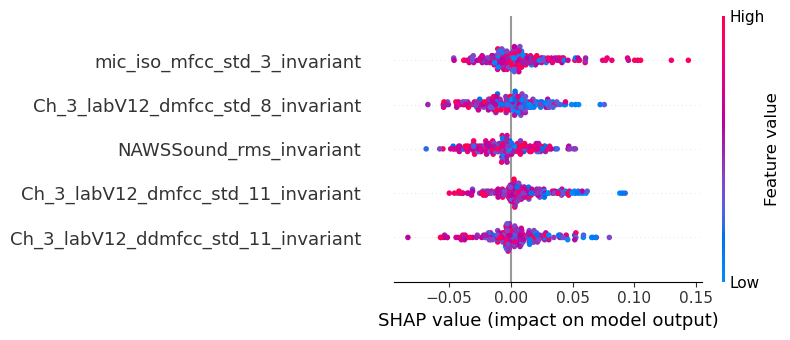

/var/folders/8h/0y2pf_1n2735m_vsyhnb7lkw0000gn/T/ipykernel_43219/2573923012.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


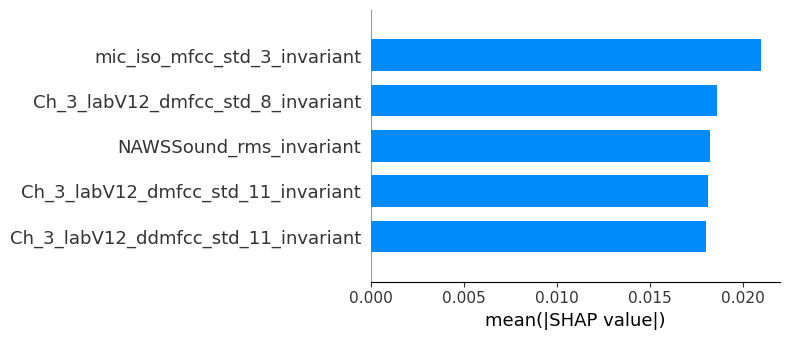

In [15]:
import matplotlib.pyplot as plt

# Re-run LOGO splits to collect all SHAP values and corresponding feature values
all_shap_values_list = []
all_feature_values_list = []

for train_idx, test_idx in logo.split(X, y_enc, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    # Clone and fit pipeline on this fold
    fold_pipeline = clone(pipeline_lr)
    fold_pipeline.fit(X_train, y_train)

    # Get the transformed features (after feature selection and scaling, before PCA)
    feature_selector = fold_pipeline.named_steps["feature_selector"]
    scaler = fold_pipeline.named_steps["scaler"]

    X_test_selected = feature_selector.transform(X_test)
    X_test_scaled = scaler.transform(X_test_selected)

    # Get full transformed features (through PCA)
    X_train_transformed = fold_pipeline[:-1].transform(X_train)
    X_test_transformed = fold_pipeline[:-1].transform(X_test)

    # Extract the FITTED logistic regression model
    lr_model = fold_pipeline.named_steps["clf"].estimator_

    # Compute SHAP values
    masker = shap.maskers.Independent(data=X_train_transformed)
    explainer = shap.Explainer(lr_model.predict_proba, masker)
    shap_values = explainer(X_test_transformed)

    # Get SHAP values for positive class
    fold_shap = shap_values.values[:, :, 1]

    # Project SHAP values back to original feature space
    pca = fold_pipeline.named_steps["pca"]
    components = pca.components_

    # Project each sample's SHAP values back to original features
    original_shap = fold_shap @ components  # shape: (n_samples, n_features)

    all_shap_values_list.append(original_shap)
    all_feature_values_list.append(X_test_scaled)

# Concatenate all folds
all_shap_values = np.concatenate(all_shap_values_list, axis=0)
all_feature_values = np.concatenate(all_feature_values_list, axis=0)

# Get feature names
selected_features = feature_selector.get_feature_names_out()

# Create SHAP summary plot (beeswarm plot - red/blue) - TOP 5 ONLY
plt.figure(figsize=(10, 6))
shap.summary_plot(
    all_shap_values,
    all_feature_values,
    feature_names=selected_features,
    max_display=5,  # Show only top 5 features
    show=False,
)
plt.tight_layout()
plt.show()

# Alternative: Bar plot showing mean absolute SHAP values - TOP 5 ONLY
plt.figure(figsize=(10, 5))
shap.summary_plot(
    all_shap_values,
    all_feature_values,
    feature_names=selected_features,
    plot_type="bar",
    max_display=5,  # Show only top 5 features
    show=False,
)
# Set custom x-label
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.show()

/var/folders/8h/0y2pf_1n2735m_vsyhnb7lkw0000gn/T/ipykernel_43219/988174741.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


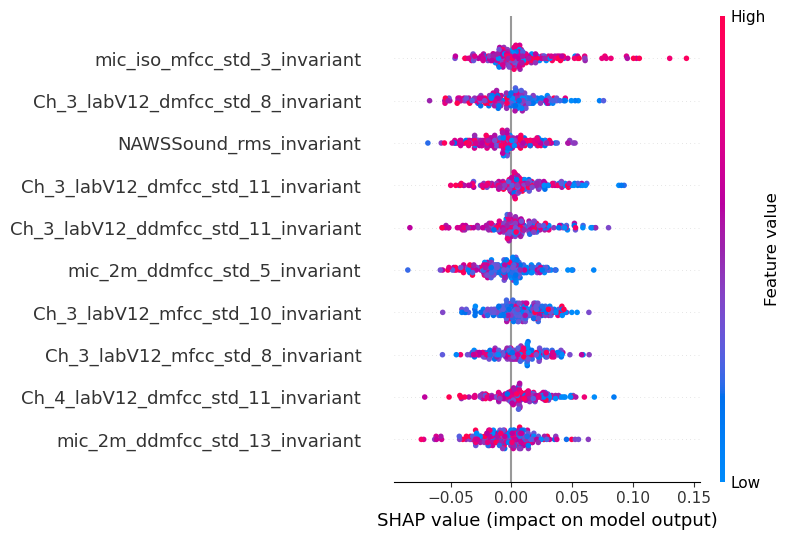

/var/folders/8h/0y2pf_1n2735m_vsyhnb7lkw0000gn/T/ipykernel_43219/988174741.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


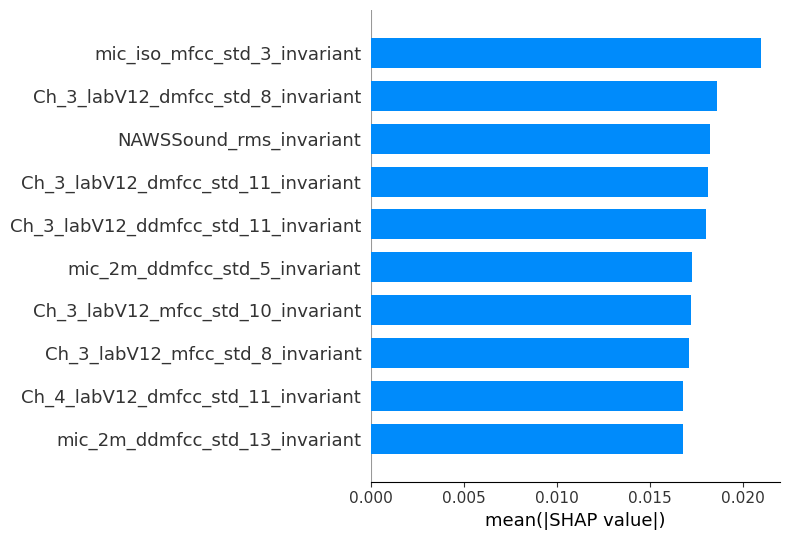

In [19]:
# Create SHAP summary plot (beeswarm plot - red/blue) - TOP 5 ONLY
plt.figure(figsize=(10, 6))
shap.summary_plot(
    all_shap_values,
    all_feature_values,
    feature_names=selected_features,
    max_display=10,  # Show only top 5 features
    show=False,
)
plt.tight_layout()
plt.show()

# Alternative: Bar plot showing mean absolute SHAP values - TOP 5 ONLY
plt.figure(figsize=(10, 5))
shap.summary_plot(
    all_shap_values,
    all_feature_values,
    feature_names=selected_features,
    plot_type="bar",
    max_display=10,  # Show only top 5 features
    show=False,
)
# Set custom x-label
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.show()

## TabPFN Importances

In [21]:
best_params = (
    pl.read_csv("tabpfn_logo_vehicle_results.csv")
    .sort("mean_test_weighted_f1", descending=True)
    .select(pl.col(r"^param_.*$"))
    .head(1)
    .to_dict()
)
best_params = {k.split("param_")[-1]: v[0] for k, v in best_params.items()}
best_params

{'clf__balance_probabilities': True,
 'clf__n_estimators': 2,
 'feature_selector__feature_set': 'cleaned_invariant+speed'}

In [ ]:
fs = FeatureSubsetSelector(feature_sets=FEATURE_SETS, feature_set="cleaned_invariant+speed")
tabpfn = TabPFNClassifier(device=device, n_estimators=1, balance_probabilities=True)
attribute_names = FEATURE_SETS[best_params["feature_selector__feature_set"]]

In [27]:
r = permutation_importance(
    tabpfn, fs.transform(X), y_enc, scoring="f1_weighted", n_repeats=1, n_jobs=1
)